# Demo: Gravitational Wave Spectrum

This notebook demonstrates how to compute and compare the predicted stochastic gravitational wave background from the dark $U(1)$ FOPT using `GWFromParams`.

**Pipeline step:** Final layer — takes the macroscopic FOPT parameters $(T_n, \alpha, \beta/H)$ from `demo_FOPT_params.ipynb` and produces the GW power spectrum $h^2\Omega_{\rm GW}(f)$.

**Modules used:** `src/RGE/GW_RGE_spectrum.py`

**Three GW sources are included:**
- Bubble wall collisions (scalar field gradient energy)
- Sound waves in the plasma
- MHD turbulence

**Contents:**
1. Spectrum from a single set of FOPT parameters
2. Comparison of multiple loop orders / renormalization schemes vs NANOGrav-15yr
3. Renormalization-scale uncertainty bands

In [37]:
%load_ext autoreload
%autoreload 2

%run startup.py

from scipy.stats import gaussian_kde

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
startup.py loaded: numpy, scipy, matplotlib, and all project modules are ready.
  Use new_figure() to create pre-formatted plots.


In [38]:
# Instantiate the GW spectrum calculator
gw = gw_spec.GWFromParams()

# Frequency array covering the PTA and LISA bands
f = np.logspace(-11, -6, 200)

In [39]:
# ── Live FOPT parameter computation at gD = 0.6 ─────────────────────────────
# All HT-Espinosa and ODE+HT values are calculated here directly.
# Only DRalgo entries (OPA, 1-L, 2-L) remain hardcoded below.
from src.RGE.BounceODE_RGE import BounceODEHighT

veff_obj = veff.VeffRGE(vt_table_path="VT_integralNumeric.dat")
fopt_ht  = fopt_real.FOPTUtilities(veff_obj=veff_obj)
fopt_ode = fopt_real.FOPTUtilities(
    veff_obj=veff_obj,
    solver_ht=BounceODEHighT(veff=veff_obj),
)

gD_ref = 0.6
ls0    = 1e-10

def _compute_fopt(fopt_instance, gD, scale, is_HT, ls0):
    Tn = fopt_instance.nucTemp(gD=gD, is_HT=is_HT, scale=scale, ls0=ls0)
    if not np.isfinite(Tn):
        return None
    return (
        float(Tn),
        float(fopt_instance.alpha(Tn, gD, is_HT=is_HT, scale=scale, ls0=ls0)),
        float(fopt_instance.beta( Tn, gD, is_HT=is_HT, scale=scale, ls0=ls0)),
    )

# Three renormalization scales: mu = (pi/4)*T, pi*T, 4*pi*T
_scales = {"lo": np.pi/4, "mid": np.pi, "hi": 4*np.pi}

print(f"Computing HT (Espinosa) at gD={gD_ref} ...")
ht_params = {k: _compute_fopt(fopt_ht, gD_ref, v, True, ls0) for k, v in _scales.items()}
for k, p in ht_params.items():
    tag = f"mu={_scales[k]/np.pi:.2f}*pi*T"
    print(f"  {tag}:  Tn={p[0]:.5f}  alpha={p[1]:.2e}  beta/H={p[2]:.1f}" if p else f"  {tag}: FAILED")

print(f"\nComputing ODE + HT at gD={gD_ref} ...")
ode_params = {k: _compute_fopt(fopt_ode, gD_ref, v, True, ls0) for k, v in _scales.items()}
for k, p in ode_params.items():
    tag = f"mu={_scales[k]/np.pi:.2f}*pi*T"
    print(f"  {tag}:  Tn={p[0]:.5f}  alpha={p[1]:.2e}  beta/H={p[2]:.1f}" if p else f"  {tag}: FAILED")


Computing HT (Espinosa) at gD=0.6 ...


/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/src/RGE/BounceSolHighT_RGE.py:201: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  result = quad(integrand, 0, phi0, limit=5_000, epsrel=1e-6, epsabs=1e-6)[0]
/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/src/RGE/BounceSolHighT_RGE.py:201: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  result = quad(integrand, 0, phi0, limit=5_000, epsrel=1e-6, epsabs=1e-6)[0]


  mu=0.25*pi*T:  Tn=0.01191  alpha=1.67e+05  beta/H=43.9
  mu=1.00*pi*T:  Tn=0.00934  alpha=2.65e+05  beta/H=41.6
  mu=4.00*pi*T:  Tn=0.00761  alpha=4.00e+05  beta/H=39.5

Computing ODE + HT at gD=0.6 ...


/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/src/RGE/BounceODE_RGE.py:163: RuntimeWarning: overflow encountered in scalar multiply
  return dm2val * m2val * (2.0 * (log_term - c) + 1.0)
/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/src/RGE/BounceODE_RGE.py:168: RuntimeWarning: invalid value encountered in scalar multiply
  + 3.0 * _dcw(m3, dm3, 5.0 / 6.0)
/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/src/RGE/BounceODE_RGE.py:179: RuntimeWarning: overflow encountered in scalar multiply
  + 3.0 * _dJBhighexp_dy(y3) * dm3
/Users/ramirezmaura/Documents/Projects/Supercool_transitions/codes/FOPT_Dark_Photon_DRalgo/src/RGE/BounceODE_RGE.py:194: RuntimeWarning: invalid value encountered in scalar add
  return dVt + dVcw + dVhT + dVd


  mu=0.25*pi*T:  Tn=0.01227  alpha=1.46e+05  beta/H=44.2
  mu=1.00*pi*T:  Tn=0.00965  alpha=2.29e+05  beta/H=42.0
  mu=4.00*pi*T:  Tn=0.00785  alpha=3.51e+05  beta/H=40.2


## 1. Spectrum from a single set of FOPT parameters

Load the output of `demo_FOPT_params.ipynb` and compute the full GW spectrum for one representative $g_D$ value.

`gw.spectra(Tn, alpha, betaH)` returns four callables:
`(h2_total, h2_bubble, h2_sw, h2_turb)` as functions of frequency $f$.

In [40]:
# Load parameter scan from demo_FOPT_params output
try:
    fopt_data = np.loadtxt("../data/final_data/gD_Tn_alpha_beta_RGE_piT_HT_all.dat")
    gD_scan, Tn_scan, alpha_scan, beta_scan = fopt_data.T
    print(f"Loaded {len(gD_scan)} parameter points")
except FileNotFoundError:
    print("Run demo_FOPT_params.ipynb first to generate the parameter file.")
    print("Using hard-coded example values instead.")
    # Example values for gD = 0.8 (high-T, mu = pi)
    gD_scan   = np.array([0.8])
    Tn_scan   = np.array([0.118])
    alpha_scan = np.array([5.6])
    beta_scan  = np.array([133.8])

Loaded 20 parameter points


gD = 0.789,  Tn = 0.10526,  alpha = 8.949e+00,  beta = 121.94


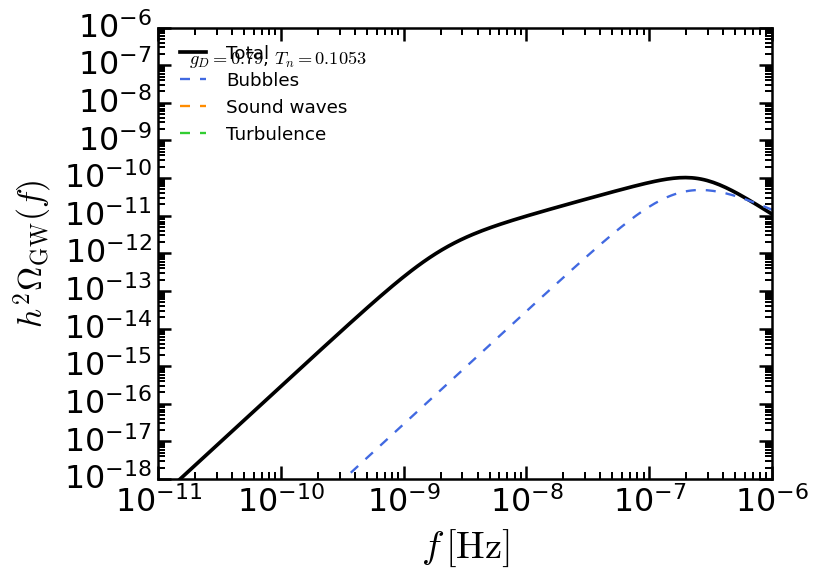

In [41]:
# Pick one gD point close to 0.8
idx_single = np.argmin(np.abs(gD_scan - 0.8))
Tn_ex, alpha_ex, beta_ex = Tn_scan[idx_single], alpha_scan[idx_single], beta_scan[idx_single]
print(f"gD = {gD_scan[idx_single]:.3f},  Tn = {Tn_ex:.5f},  alpha = {alpha_ex:.3e},  beta = {beta_ex:.2f}")

h2_tot, h2_bub, h2_sw, h2_turb, h2_pT = gw.spectra(Tn_ex, alpha_ex, beta_ex, kappa_col=1.0)

fig, ax = new_figure(figsize=(7, 5), dpi=120)
fig.patch.set_facecolor('white')

ax.plot(f, [h2_tot(fi)  for fi in f], color='black',     lw=2.2, label='Total')
ax.plot(f, [h2_bub(fi)  for fi in f], color='royalblue', lw=1.4, ls='--', label='Bubbles')
ax.plot(f, [h2_sw(fi)   for fi in f], color='darkorange', lw=1.4, ls='--', label='Sound waves')
ax.plot(f, [h2_turb(fi) for fi in f], color='limegreen',  lw=1.4, ls='--', label='Turbulence')

ax.text(0.05, 0.92, fr'$g_D={gD_scan[idx_single]:.2f}$, $T_n={Tn_ex:.4f}$',
        transform=ax.transAxes, fontsize=11)

ps.apply_standard_formatting(
    ax,
    xlog=True, ylog=True,
    xlabel=r'$f\,[{\rm Hz}]$',
    ylabel=r'$h^2\Omega_{\rm GW}(f)$',
    ylim=(1e-18, 1e-6),
    xlim=(1e-11, 1e-6),
)
ax.legend(loc='upper left', frameon=False, fontsize=11)
plt.tight_layout()

## 2. Multiple loop orders vs NANOGrav-15yr

Compare the GW spectra from different treatments of the effective potential (4D HT daisy, 1-loop LO/NLO, 2-loop NLO) against the NANOGrav-15yr posterior. The parameters below are obtained from separate runs of `demo_FOPT_params` with different perturbative schemes, all at $g_D = 0.6$.

In [44]:
# Load NANOGrav-15yr posterior samples
data_ng = np.loadtxt("data/other_data/NG15.dat")
logfreqs_ng = data_ng[:, 0]
freqs_ng    = 10**logfreqs_ng
samples_ng  = 10**data_ng[:, 1:]   # convert log10 to linear

In [45]:
# FOPT parameters for gD ≈ 0.6.
# DRalgo entries are from separate previous runs and kept hardcoded.
# HT (Espinosa) and ODE + HT are computed in the cell above.
spectra_params = {
    "OPA":           (0.004925878072664542, 327835.9, 32.19),
    "1-L (LO)":      (0.008657363356312823, 169679.0, 41.08),
    "1-L (NLO)":     (0.012347489336953803,  41006.8, 44.38),
    "2-L (NLO)":     (0.009398665817136863, 122153.5, 43.15),
    "2-L (Mixed)":   (0.009314813138090460, 126611.8, 43.05),
}
if ht_params["mid"]:  spectra_params["HT (Espinosa)"] = ht_params["mid"]
if ode_params["mid"]: spectra_params["ODE + HT"]      = ode_params["mid"]

plot_styles = {
    "OPA":            {"color": "orange",       "lw": 3,   "ls": ":"},
    "1-L (LO)":       {"marker": r"$\ast$",    "color": "royalblue",  "s": 80},
    "1-L (NLO)":      {"marker": "d", "edgecolor": "navy",    "facecolor": "none", "lw": 1.0, "s": 65},
    "2-L (NLO)":      {"marker": "s", "edgecolor": "#8B1E3F", "facecolor": "none", "lw": 1.0, "s": 65},
    "2-L (Mixed)":    {"marker": "o", "edgecolor": "#C99E10", "facecolor": "none", "lw": 1,   "s": 80},
    "HT (Espinosa)":  {"color": "steelblue",    "lw": 2.0, "ls": "--"},
    "ODE + HT":       {"color": "mediumpurple", "lw": 1.8, "ls": (0, (3,1,1,1))},
}


Saved: plots/GW_comparison_loop_orders.pdf


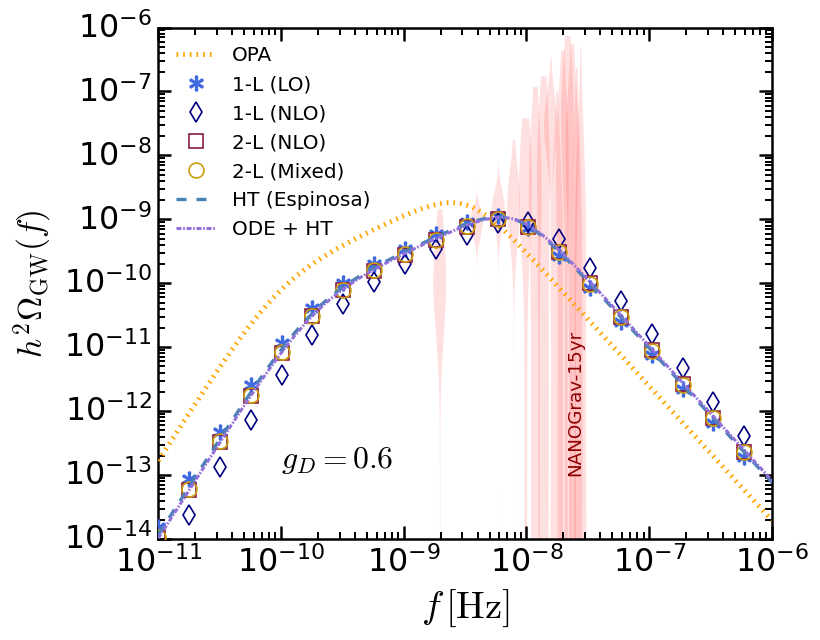

In [46]:
# Build GW spectra
spectra_funcs = {}
for key, (Tn_k, alpha_k, beta_k) in spectra_params.items():
    h2_tot_k, *_ = gw.spectra(Tn_k, alpha_k, beta_k, kappa_col=1.0)
    spectra_funcs[key] = h2_tot_k

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 5.5), dpi=120)
fig.patch.set_facecolor('white')

# NANOGrav-15yr violin distributions
for i in range(len(freqs_ng)):
    y = samples_ng[i]
    y = y[y > 0]
    if len(y) < 10:
        continue
    kde  = gaussian_kde(np.log10(y))
    yv   = np.linspace(np.log10(y.min()), np.log10(y.max()), 200)
    dens = kde(yv)
    w    = freqs_ng[i] * 0.12
    dens_scaled = dens / dens.max() * w
    ax.fill_betweenx(10**yv,
                     freqs_ng[i] - dens_scaled,
                     freqs_ng[i] + dens_scaled,
                     alpha=0.12, color='red', edgecolor='none', zorder=1)

# GW curves
_step = max(1, len(f) // 20)   # ~20 markers per curve
for key, h2func in spectra_funcs.items():
    style  = plot_styles[key]
    y_vals = np.array([h2func(fi) for fi in f])
    if "marker" in style:
        ax.plot(f[::_step], y_vals[::_step],
                linestyle='none',
                marker=style["marker"],
                ms=style.get("s", 35)**0.5,
                markeredgecolor=style.get("edgecolor", style.get("color", None)),
                markerfacecolor=style.get("facecolor", style.get("color", None)),
                markeredgewidth=style.get("lw", 1.0),
                color=style.get("color", None),
                label=key, zorder=3)
    else:
        ax.plot(f, y_vals, label=key,
                color=style.get("color", None),
                lw=style.get("lw", 2.0),
                ls=style.get("ls", "-"),
                zorder=3)

ax.text(1e-10, 1e-13, r'$g_D = 0.6$', fontsize=19, ha='left', va='bottom')
ax.text(2.1e-8, 1e-13, 'NANOGrav-15yr', fontsize=11, ha='left', va='bottom',
        rotation=90, color='darkred')

ps.apply_standard_formatting(
    ax,
    xlog=True, ylog=True,
    xlabel=r'$f\,[{\rm Hz}]$',
    ylabel=r'$h^2\Omega_{{\rm GW}}(f)$',
    ylim=(1e-14, 1e-6),
    xlim=(1e-11, 1e-6),
)
ax.legend(loc='upper left', frameon=False, numpoints=1, fontsize=12, ncol=1)
plt.tight_layout()
#plt.savefig("../plots/GW_comparison_loop_orders.pdf", dpi=300, bbox_inches='tight', facecolor='white')
print("Saved: plots/GW_comparison_loop_orders.pdf")


## 3. Renormalization-scale uncertainty bands

For the high-$T$ (daisy) and 2-loop (NLO) treatments, we vary $\mu$ over $[\pi/4 T,\, \pi T,\, 4\pi T]$ to estimate the perturbative uncertainty. The spread of the GW spectrum quantifies residual scale dependence.

In [11]:
# DRalgo 2-loop (NLO) band — hardcoded from separate runs
Tn_2L,  a_2L,  b_2L  = 0.009398665817136863, 122153.5, 43.15   # central
Tn_2L1, a_2L1, b_2L1 = 0.009107556658922054, 138536.0, 43.06   # mu = 0.25 mu_match
Tn_2L2, a_2L2, b_2L2 = 0.009298674143090531, 127493.0, 43.21   # mu = 4 mu_match

# OPA reference — hardcoded
Tn_OPA, a_OPA, b_OPA = 0.004925878072664542, 327835.9, 32.19

# HT (Espinosa) and ODE + HT bands — from live computation above
ht_lo,  ht_mid,  ht_hi  = ht_params["lo"],  ht_params["mid"],  ht_params["hi"]
ode_lo, ode_mid, ode_hi = ode_params["lo"], ode_params["mid"], ode_params["hi"]


In [36]:
def _build(params):
    if params is None:
        return None
    h, *_ = gw.spectra(*params, kappa_col=1.0)
    return h

def eval_spec(h2func):
    if h2func is None:
        return np.full(len(f), np.nan), np.zeros(len(f), dtype=bool)
    y = np.array([h2func(fi) for fi in f])
    return y, np.isfinite(y) & (y > 0)

# HT Espinosa band
h2_ht_lo,  h2_ht_mid,  h2_ht_hi  = _build(ht_lo),  _build(ht_mid),  _build(ht_hi)
# ODE + HT band
h2_ode_lo, h2_ode_mid, h2_ode_hi = _build(ode_lo), _build(ode_mid), _build(ode_hi)
# DRalgo references
h2_2L,  *_ = gw.spectra(Tn_2L,  a_2L,  b_2L,  kappa_col=1.0)
h2_2L1, *_ = gw.spectra(Tn_2L1, a_2L1, b_2L1, kappa_col=1.0)
h2_2L2, *_ = gw.spectra(Tn_2L2, a_2L2, b_2L2, kappa_col=1.0)
h2_OPA, *_ = gw.spectra(Tn_OPA, a_OPA, b_OPA, kappa_col=1.0)

y_ht_lo,  m_ht_lo  = eval_spec(h2_ht_lo)
y_ht_mid, m_ht_mid = eval_spec(h2_ht_mid)
y_ht_hi,  m_ht_hi  = eval_spec(h2_ht_hi)
y_ode_lo,  m_ode_lo  = eval_spec(h2_ode_lo)
y_ode_mid, m_ode_mid = eval_spec(h2_ode_mid)
y_ode_hi,  m_ode_hi  = eval_spec(h2_ode_hi)
y_2L,  m_2L  = eval_spec(h2_2L)
y_2L1, m_2L1 = eval_spec(h2_2L1)
y_2L2, m_2L2 = eval_spec(h2_2L2)
y_OPA, m_OPA = eval_spec(h2_OPA)


In [35]:
fig, ax = plt.subplots(figsize=(7, 5.5), dpi=120)
fig.patch.set_facecolor('white')

# NANOGrav-15yr violins
for i in range(len(freqs_ng)):
    y = samples_ng[i]
    y = y[y > 0]
    if len(y) < 10:
        continue
    kde  = gaussian_kde(np.log10(y))
    yv   = np.linspace(np.log10(y.min()), np.log10(y.max()), 200)
    dens = kde(yv)
    w    = freqs_ng[i] * 0.12
    dens_scaled = dens / dens.max() * w
    ax.fill_betweenx(10**yv,
                     freqs_ng[i] - dens_scaled,
                     freqs_ng[i] + dens_scaled,
                     alpha=0.12, color='red', edgecolor='none', zorder=1)

# HT (Espinosa) central + band
if m_ht_mid.any():
    ax.plot(f[m_ht_mid], y_ht_mid[m_ht_mid], color='steelblue', ls='--', lw=2.2,
            label=r'HT (Espinosa), $\mu=\pi T$')
m_ht_band = m_ht_lo & m_ht_hi
if m_ht_band.any():
    ax.fill_between(f[m_ht_band],
                    np.minimum(y_ht_lo, y_ht_hi)[m_ht_band],
                    np.maximum(y_ht_lo, y_ht_hi)[m_ht_band],
                    color='steelblue', alpha=0.20, edgecolor='none', zorder=2,
                    label=r'HT (Esp.) band $[\pi/4,\,4\pi]\,T$')

# ODE + HT central + band
if m_ode_mid.any():
    ax.plot(f[m_ode_mid], y_ode_mid[m_ode_mid], color='mediumpurple',
            ls=(0,(3,1,1,1)), lw=2.0, label=r'ODE + HT, $\mu=\pi T$')
m_ode_band = m_ode_lo & m_ode_hi
if m_ode_band.any():
    ax.fill_between(f[m_ode_band],
                    np.minimum(y_ode_lo, y_ode_hi)[m_ode_band],
                    np.maximum(y_ode_lo, y_ode_hi)[m_ode_band],
                    color='mediumpurple', alpha=0.20, edgecolor='none', zorder=2,
                    label=r'ODE + HT band')

# 2-loop (NLO) central + band — DRalgo
ax.plot(f[m_2L],  y_2L[m_2L],  color='purple', ls=':', lw=2.2,
        label=r'2-L (NLO), central')
m_2L_band = m_2L1 & m_2L2
if m_2L_band.any():
    ax.fill_between(f[m_2L_band],
                    np.minimum(y_2L1, y_2L2)[m_2L_band],
                    np.maximum(y_2L1, y_2L2)[m_2L_band],
                    color='purple', alpha=0.18, edgecolor='none', zorder=2,
                    label=r'2-L (NLO) band')

# OPA reference
if m_OPA.any():
    ax.plot(f[m_OPA], y_OPA[m_OPA], color='orange', ls=':', lw=2.5, label='OPA')

ax.text(1e-10, 1e-13, r'$g_D = 0.6$', fontsize=19, ha='left', va='bottom')
ax.text(2.1e-8, 1e-13, 'NANOGrav-15yr', fontsize=11, ha='left', va='bottom',
        rotation=90, color='darkred')

ps.apply_standard_formatting(
    ax,
    xlog=True, ylog=True,
    xlabel=r'$f\,[{\rm Hz}]$',
    ylabel=r'$h^2\Omega_{{\rm GW}}(f)$',
    ylim=(1e-14, 1e-6),
    xlim=(1e-11, 1e-6),
)
ax.legend(loc='upper left', frameon=False, fontsize=11, ncol=1)
plt.tight_layout()
plt.savefig("../plots/GW_scale_uncertainty.pdf", dpi=300, bbox_inches='tight', facecolor='white')
print("Saved: plots/GW_scale_uncertainty.pdf")
